In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

from sklearn.preprocessing import MinMaxScaler

In [2]:
# Reading csv's and shapefile
fl_nri = pd.read_csv("NRI_Table_CensusTracts_Florida.csv")
fl_svi = pd.read_csv("Florida.csv")
wy_nri = pd.read_csv("NRI_Table_CensusTracts_Wyoming.csv")
wy_svi = pd.read_csv("Wyoming.csv")
la_nri = pd.read_csv("NRI_Table_CensusTracts_Louisiana.csv")
la_svi = pd.read_csv("Louisiana.csv")
tracts = gpd.read_file('NRI_Shapefile_CensusTracts.shp')
tracts = tracts.replace(-9999, np.nan)
nri_dictionary = pd.read_csv("NRIDataDictionary.csv")

In [3]:
# Prepares merge of NRI and SVI datasets by using a similar column
fl_nri['STCNTY'] = fl_nri['STCOFIPS']
wy_nri['STCNTY'] = wy_nri['STCOFIPS']
la_nri['STCNTY'] = la_nri['STCOFIPS']

# Merges NRI and SVI datasets by using STCNTY column key
fl_complete_data = pd.merge(fl_nri, fl_svi, on = 'STCNTY', suffixes=('', '_right'))
wy_complete_data = pd.merge(wy_nri, wy_svi, on = 'STCNTY', suffixes=('', '_right'))
la_complete_data = pd.merge(la_nri, la_svi, on = 'STCNTY', suffixes=('', '_right'))

In [4]:
# This finds all the columns in the merged datasets that are numbers
num_cols = fl_complete_data.select_dtypes(include=["int64", "float64"]).columns

# Using the knowledge of all the columns that are numbers, we replace all the NA values with the median of the column
fl_complete_data[num_cols] = fl_complete_data[num_cols].fillna(fl_complete_data[num_cols].median())
wy_complete_data[num_cols] = wy_complete_data[num_cols].fillna(wy_complete_data[num_cols].median())
la_complete_data[num_cols] = la_complete_data[num_cols].fillna(la_complete_data[num_cols].median())

In [5]:
# This was used to fix a warning of the files being 
fl_complete_data = fl_complete_data.drop_duplicates(subset="TRACTFIPS").copy()
wy_complete_data = wy_complete_data.drop_duplicates(subset="TRACTFIPS").copy()
la_complete_data = la_complete_data.drop_duplicates(subset="TRACTFIPS").copy()

In [6]:
print(nri_dictionary[nri_dictionary["Field Name"].str.contains("SWND_RISKS|SWND_EXPT|SWND_AFREQ|SWND_HLRP|LNDS_RISKS|LNDS_EXPT|LNDS_AFREQ|LNDS_HLRP|HRCN_RISKS|HRCN_EXPT|HRCN_AFREQ|HRCN_HLRP|SOVI_SCORE|RESL_SCORE")][["Field Name", "Field Alias"]])

     Field Name                                     Field Alias
35   SOVI_SCORE                    Social Vulnerability - Score
38   RESL_SCORE                    Community Resilience - Score
204  HRCN_AFREQ                Hurricane - Annualized Frequency
209   HRCN_EXPT                    Hurricane - Exposure - Total
212   HRCN_HLRP    Hurricane - Historic Loss Ratio - Population
227  HRCN_RISKS        Hurricane - Hazard Type Risk Index Score
252  LNDS_AFREQ                Landslide - Annualized Frequency
256   LNDS_EXPT                    Landslide - Exposure - Total
259   LNDS_HLRP    Landslide - Historic Loss Ratio - Population
271  LNDS_RISKS        Landslide - Hazard Type Risk Index Score
322  SWND_AFREQ              Strong Wind - Annualized Frequency
327   SWND_EXPT                  Strong Wind - Exposure - Total
330   SWND_HLRP  Strong Wind - Historic Loss Ratio - Population
345  SWND_RISKS      Strong Wind - Hazard Type Risk Index Score


In [7]:
scaler = MinMaxScaler(feature_range=(0,1))
scaler100 = MinMaxScaler(feature_range=(0, 100))

# Florida Risk Calculations
fl_complete_data["SOVI_norm"] = scaler.fit_transform(fl_complete_data[["SOVI_SCORE"]])
fl_complete_data["RESL_norm"] = scaler.fit_transform(fl_complete_data[["RESL_SCORE"]])


fl_complete_data["SWND_hazard_norm"] = scaler.fit_transform(
    (fl_complete_data[["SWND_EXPT"]] * fl_complete_data[["SWND_AFREQ"]].values * fl_complete_data[["SWND_HLRP"]].values).fillna(0)
)
fl_complete_data["LNDS_hazard_norm"] = scaler.fit_transform(
    (fl_complete_data[["LNDS_EXPT"]] * fl_complete_data[["LNDS_AFREQ"]].values * fl_complete_data[["LNDS_HLRP"]].values).fillna(0)
)


fl_complete_data["new_SWND_RISKS"] = (
    0.40 * fl_complete_data["SWND_hazard_norm"] +
    0.45 * fl_complete_data["SOVI_norm"] -
    0.15 * fl_complete_data["RESL_norm"]
).clip(lower=0)  # prevent negatives

fl_complete_data["new_LNDS_RISKS"] = (
    0.40 * fl_complete_data["LNDS_hazard_norm"] +
    0.45 * fl_complete_data["SOVI_norm"] -
    0.15 * fl_complete_data["RESL_norm"]
).clip(lower=0)


fl_complete_data["new_SWND_RISKS"] = scaler100.fit_transform(fl_complete_data[["new_SWND_RISKS"]])
fl_complete_data["new_LNDS_RISKS"] = scaler100.fit_transform(fl_complete_data[["new_LNDS_RISKS"]])


fl_tracts_clean = tracts.to_crs("ESRI:102003")
fl_tracts_clean["TRACTFIPS"] = fl_tracts_clean["TRACTFIPS"].astype(str)
fl_complete_data["TRACTFIPS"]      = fl_complete_data["TRACTFIPS"].astype(str)


fl_tracts_clean = fl_tracts_clean.merge(
    fl_complete_data[["TRACTFIPS", "SWND_RISKS", "LNDS_RISKS", "new_SWND_RISKS", "new_LNDS_RISKS"]],
    on="TRACTFIPS",
    how="left")



# Wyoming Risk Calculations
wy_complete_data["SOVI_norm"] = scaler.fit_transform(wy_complete_data[["SOVI_SCORE"]])
wy_complete_data["RESL_norm"] = scaler.fit_transform(wy_complete_data[["RESL_SCORE"]])


wy_complete_data["SWND_hazard_norm"] = scaler.fit_transform(
    (wy_complete_data[["SWND_EXPT"]] * wy_complete_data[["SWND_AFREQ"]].values * wy_complete_data[["SWND_HLRP"]].values).fillna(0)
)


wy_complete_data["new_SWND_RISKS"] = (
    0.40 * wy_complete_data["SWND_hazard_norm"] +
    0.45 * wy_complete_data["SOVI_norm"] -
    0.15 * wy_complete_data["RESL_norm"]
).clip(lower=0)


wy_complete_data["new_SWND_RISKS"] = scaler100.fit_transform(wy_complete_data[["new_SWND_RISKS"]])


wy_tracts_clean = tracts.to_crs("ESRI:102003")
wy_tracts_clean["TRACTFIPS"] = wy_tracts_clean["TRACTFIPS"].astype(str)
wy_complete_data["TRACTFIPS"]      = wy_complete_data["TRACTFIPS"].astype(str)


wy_tracts_clean = wy_tracts_clean.merge(
    wy_complete_data[["TRACTFIPS", "SWND_RISKS", "new_SWND_RISKS"]],
    on="TRACTFIPS",
    how="left"
)



# Louisiana Risk Calculations
la_complete_data["SOVI_norm"] = scaler.fit_transform(la_complete_data[["SOVI_SCORE"]])
la_complete_data["RESL_norm"] = scaler.fit_transform(la_complete_data[["RESL_SCORE"]])


la_complete_data["HRCN_hazard_norm"] = scaler.fit_transform(
    (la_complete_data[["HRCN_EXPT"]] * la_complete_data[["HRCN_AFREQ"]].values * la_complete_data[["HRCN_HLRP"]].values).fillna(0)
)


la_complete_data["new_HRCN_RISKS"] = (
    0.40 * la_complete_data["HRCN_hazard_norm"] +
    0.45 * la_complete_data["SOVI_norm"] -
    0.15 * la_complete_data["RESL_norm"]
).clip(lower=0)


la_complete_data["new_HRCN_RISKS"] = scaler100.fit_transform(la_complete_data[["new_HRCN_RISKS"]])


la_tracts_clean = tracts.to_crs("ESRI:102003")
la_tracts_clean["TRACTFIPS"] = la_tracts_clean["TRACTFIPS"].astype(str)
la_complete_data["TRACTFIPS"]      = la_complete_data["TRACTFIPS"].astype(str)


la_tracts_clean = la_tracts_clean.merge(
    la_complete_data[["TRACTFIPS", "HRCN_RISKS", "new_HRCN_RISKS"]],
    on="TRACTFIPS",
    how="left"
)

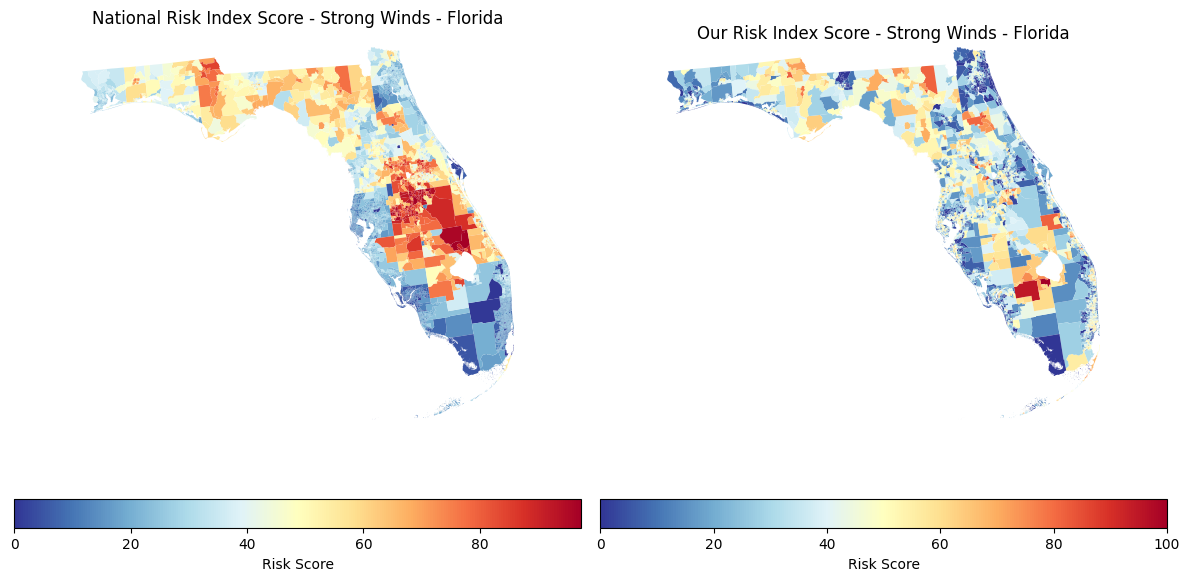

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

state_name = "Florida"

state_map = fl_tracts_clean[fl_tracts_clean["STATE"].str.lower() == state_name.lower()]

# NRI Florida Strong Winds Risk
state_map.plot(column='SWND_RISKS_x', ax=ax[0], legend=True,
                linewidth=0.1, cmap="RdYlBu_r",
                legend_kwds={'label': "Risk Score", 'orientation': "horizontal"},
                missing_kwds={'color': "lightgrey", 'label': "No Data"})

minx, miny, maxx, maxy = state_map.total_bounds
padding = 0.5
ax[0].set_xlim(minx-padding, maxx+padding)
ax[0].set_ylim(miny-padding, maxy+padding)
ax[0].set_title("National Risk Index Score - Strong Winds - Florida")
ax[0].set_axis_off()

# Our Florida Strong Winds Risk
state_map.plot(column='new_SWND_RISKS', ax=ax[1], legend=True,
                linewidth=0.1, cmap="RdYlBu_r",
                legend_kwds={'label': "Risk Score", 'orientation': "horizontal"},
                missing_kwds={'color': "lightgrey", 'label': "No Data"})

minx, miny, maxx, maxy = state_map.total_bounds
ax[1].set_xlim(minx-padding, maxx+padding)
ax[1].set_ylim(miny-padding, maxy+padding)
ax[1].set_title("Our Risk Index Score - Strong Winds - Florida")
ax[1].set_axis_off()

plt.tight_layout()
plt.show()

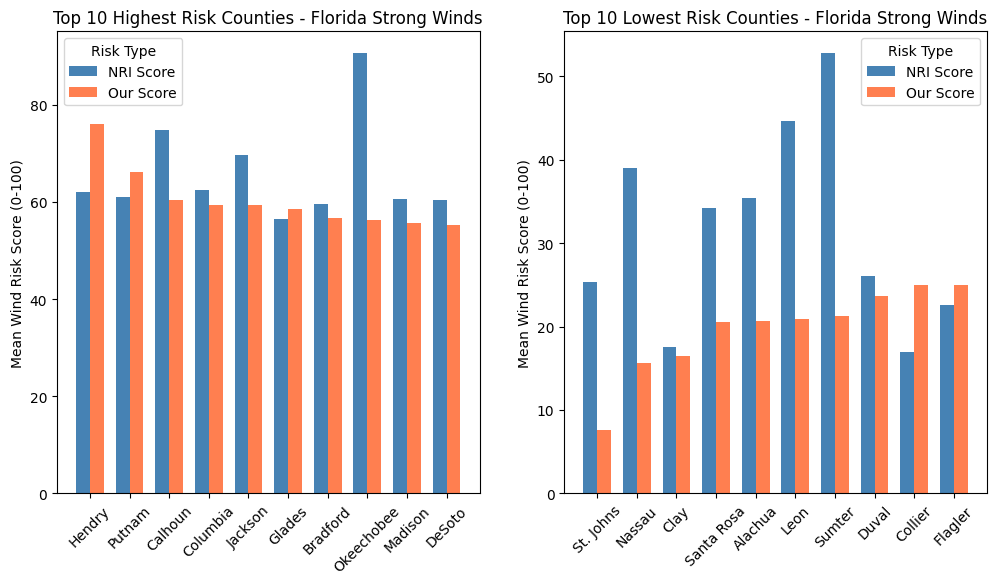

In [17]:
fl_counties_winds = fl_complete_data.groupby('COUNTY')[['SWND_RISKS', 'new_SWND_RISKS']].mean()
fl_counties_winds_top = fl_counties_winds.nlargest(10, 'new_SWND_RISKS')
fl_counties_winds_bottom = fl_counties_winds.nsmallest(10, 'new_SWND_RISKS')

fig, axes = plt.subplots(1,2,figsize=(12,6))

x = np.arange(len(fl_counties_winds_top))
width = 0.35
axes[0].bar(x - width/2, fl_counties_winds_top["SWND_RISKS"], width, label="NRI Score", color="steelblue")
axes[0].bar(x + width/2, fl_counties_winds_top["new_SWND_RISKS"], width, label="Our Score", color="coral")
axes[0].set_xticks(x)
axes[0].set_xticklabels(fl_counties_winds_top.index, rotation=45)
axes[0].set_ylabel("Mean Wind Risk Score (0-100)")
axes[0].set_title("Top 10 Highest Risk Counties - Florida Strong Winds")
axes[0].legend(title="Risk Type")


x = np.arange(len(fl_counties_winds_bottom))
axes[1].bar(x - width/2, fl_counties_winds_bottom["SWND_RISKS"], width, label="NRI Score", color="steelblue")
axes[1].bar(x + width/2, fl_counties_winds_bottom["new_SWND_RISKS"], width, label="Our Score", color="coral")
axes[1].set_xticks(x)
axes[1].set_xticklabels(fl_counties_winds_bottom.index, rotation=45)
axes[1].set_ylabel("Mean Wind Risk Score (0-100)")
axes[1].set_title("Top 10 Lowest Risk Counties - Florida Strong Winds")
axes[1].legend(title="Risk Type")

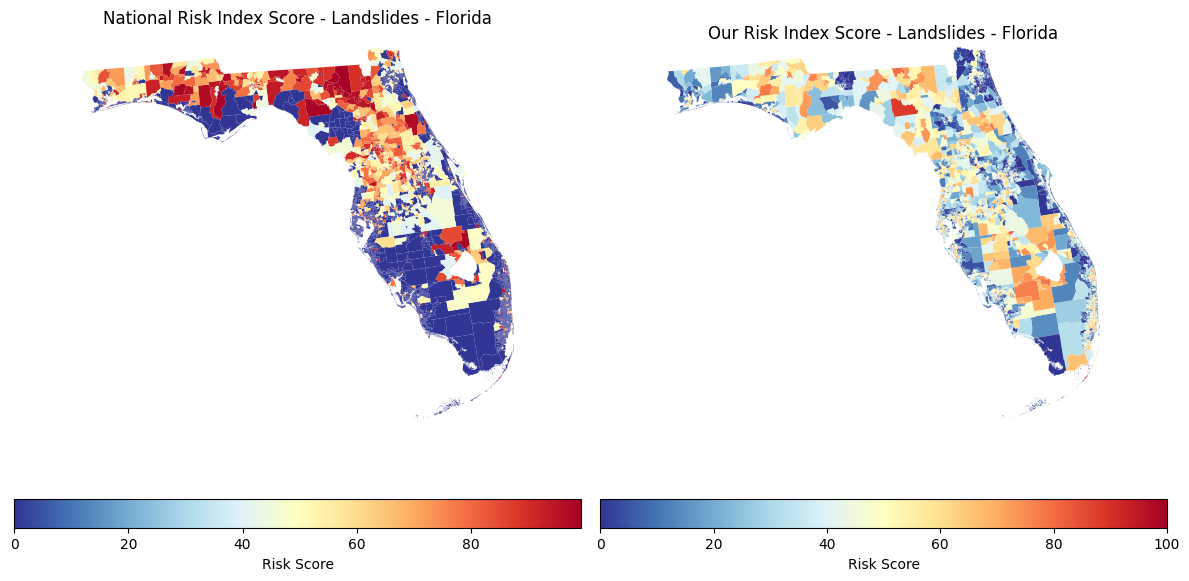

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

state_name = "Florida"

state_map = fl_tracts_clean[fl_tracts_clean["STATE"].str.lower() == state_name.lower()]

# NRI Florida Landslides Risk
state_map.plot(column='LNDS_RISKS_x', ax=ax[0], legend=True,
                linewidth=0.1, cmap="RdYlBu_r",
                legend_kwds={'label': "Risk Score", 'orientation': "horizontal"},
                missing_kwds={'color': "lightgrey", 'label': "No Data"})

minx, miny, maxx, maxy = state_map.total_bounds
padding = 0.5
ax[0].set_xlim(minx-padding, maxx+padding)
ax[0].set_ylim(miny-padding, maxy+padding)
ax[0].set_title("National Risk Index Score - Landslides - Florida")
ax[0].set_axis_off()

# Our Florida Landslides Risk
state_map.plot(column='new_LNDS_RISKS', ax=ax[1], legend=True,
                linewidth=0.1, cmap="RdYlBu_r",
                legend_kwds={'label': "Risk Score", 'orientation': "horizontal"},
                missing_kwds={'color': "lightgrey", 'label': "No Data"})

minx, miny, maxx, maxy = state_map.total_bounds
ax[1].set_xlim(minx-padding, maxx+padding)
ax[1].set_ylim(miny-padding, maxy+padding)
ax[1].set_title("Our Risk Index Score - Landslides - Florida")
ax[1].set_axis_off()

plt.tight_layout()
plt.show()

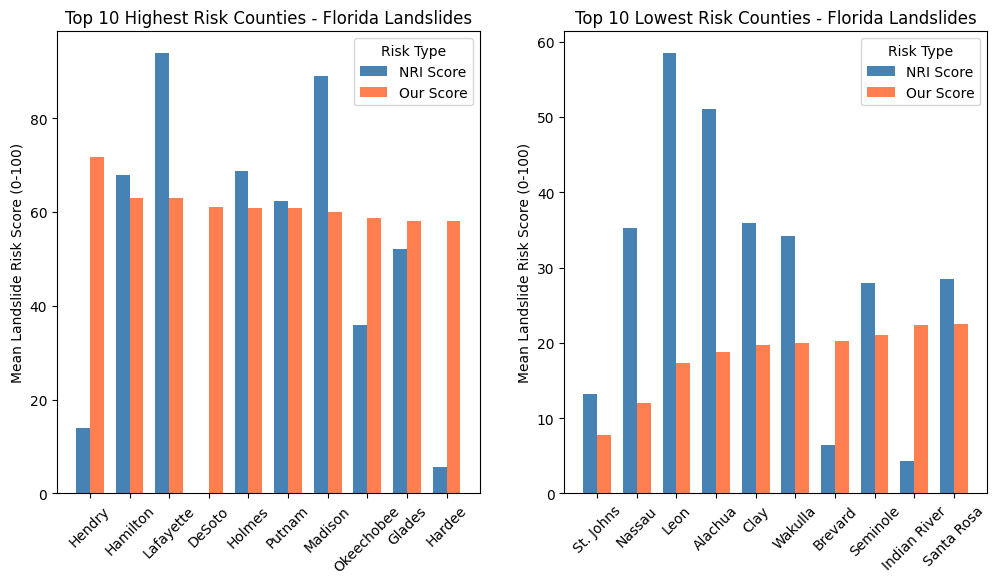

In [20]:
fl_counties_landslides = fl_complete_data.groupby('COUNTY')[['LNDS_RISKS', 'new_LNDS_RISKS']].mean()
fl_counties_landslides_top = fl_counties_landslides.nlargest(10, 'new_LNDS_RISKS')
fl_counties_landslides_bottom = fl_counties_landslides.nsmallest(10, 'new_LNDS_RISKS')

fig, axes = plt.subplots(1,2,figsize=(12,6))

x = np.arange(len(fl_counties_landslides_top))
width = 0.35
axes[0].bar(x - width/2, fl_counties_landslides_top["LNDS_RISKS"], width, label="NRI Score", color="steelblue")
axes[0].bar(x + width/2, fl_counties_landslides_top["new_LNDS_RISKS"], width, label="Our Score", color="coral")
axes[0].set_xticks(x)
axes[0].set_xticklabels(fl_counties_landslides_top.index, rotation=45)
axes[0].set_ylabel("Mean Landslide Risk Score (0-100)")
axes[0].set_title("Top 10 Highest Risk Counties - Florida Landslides")
axes[0].legend(title="Risk Type")


x = np.arange(len(fl_counties_landslides_bottom))
axes[1].bar(x - width/2, fl_counties_landslides_bottom["LNDS_RISKS"], width, label="NRI Score", color="steelblue")
axes[1].bar(x + width/2, fl_counties_landslides_bottom["new_LNDS_RISKS"], width, label="Our Score", color="coral")
axes[1].set_xticks(x)
axes[1].set_xticklabels(fl_counties_landslides_bottom.index, rotation=45)
axes[1].set_ylabel("Mean Landslide Risk Score (0-100)")
axes[1].set_title("Top 10 Lowest Risk Counties - Florida Landslides")
axes[1].legend(title="Risk Type")

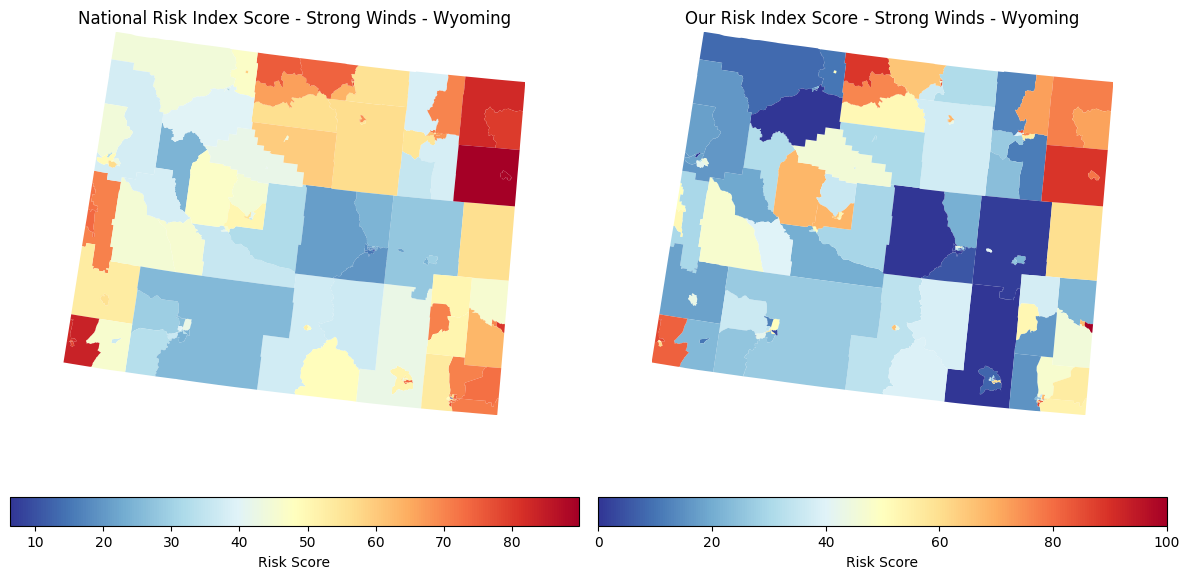

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

state_name = "Wyoming"

state_map = wy_tracts_clean[fl_tracts_clean["STATE"].str.lower() == state_name.lower()]

# NRI Wyoming Strong Winds Risk
state_map.plot(column='SWND_RISKS_x', ax=ax[0], legend=True,
                linewidth=0.1, cmap="RdYlBu_r",
                legend_kwds={'label': "Risk Score", 'orientation': "horizontal"},
                missing_kwds={'color': "lightgrey", 'label': "No Data"})

minx, miny, maxx, maxy = state_map.total_bounds
padding = 0.5
ax[0].set_xlim(minx-padding, maxx+padding)
ax[0].set_ylim(miny-padding, maxy+padding)
ax[0].set_title("National Risk Index Score - Strong Winds - Wyoming")
ax[0].set_axis_off()

# Our Florida Strong Winds Risk
state_map.plot(column='new_SWND_RISKS', ax=ax[1], legend=True,
                linewidth=0.1, cmap="RdYlBu_r",
                legend_kwds={'label': "Risk Score", 'orientation': "horizontal"},
                missing_kwds={'color': "lightgrey", 'label': "No Data"})

minx, miny, maxx, maxy = state_map.total_bounds
ax[1].set_xlim(minx-padding, maxx+padding)
ax[1].set_ylim(miny-padding, maxy+padding)
ax[1].set_title("Our Risk Index Score - Strong Winds - Wyoming")
ax[1].set_axis_off()

plt.tight_layout()
plt.show()

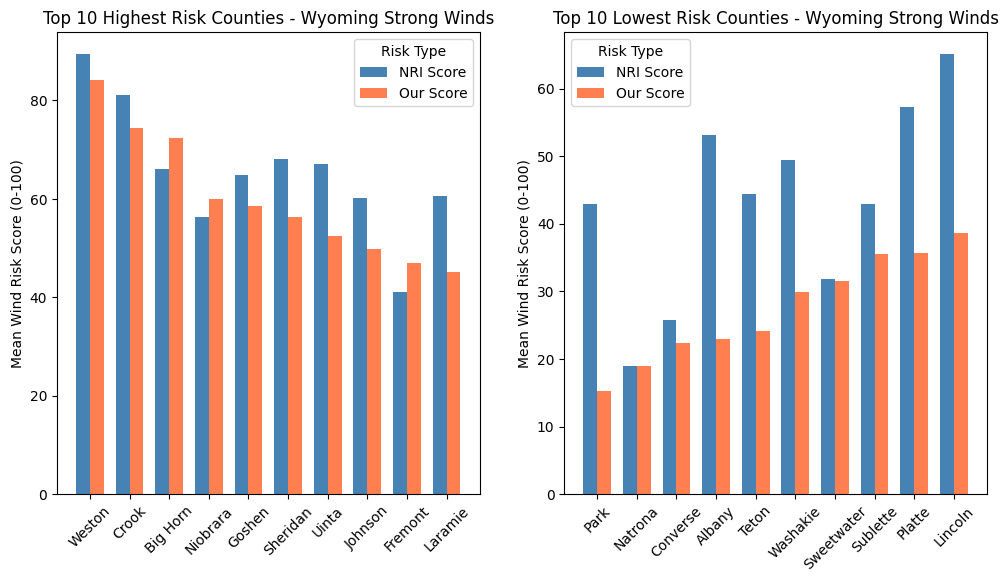

In [21]:
wy_counties_winds = wy_complete_data.groupby('COUNTY')[['SWND_RISKS', 'new_SWND_RISKS']].mean()
wy_counties_winds_top = wy_counties_winds.nlargest(10, 'new_SWND_RISKS')
wy_counties_winds_bottom = wy_counties_winds.nsmallest(10, 'new_SWND_RISKS')

fig, axes = plt.subplots(1,2,figsize=(12,6))

x = np.arange(len(wy_counties_winds_top))
width = 0.35
axes[0].bar(x - width/2, wy_counties_winds_top["SWND_RISKS"], width, label="NRI Score", color="steelblue")
axes[0].bar(x + width/2, wy_counties_winds_top["new_SWND_RISKS"], width, label="Our Score", color="coral")
axes[0].set_xticks(x)
axes[0].set_xticklabels(wy_counties_winds_top.index, rotation=45)
axes[0].set_ylabel("Mean Wind Risk Score (0-100)")
axes[0].set_title("Top 10 Highest Risk Counties - Wyoming Strong Winds")
axes[0].legend(title="Risk Type")


x = np.arange(len(wy_counties_winds_bottom))
axes[1].bar(x - width/2, wy_counties_winds_bottom["SWND_RISKS"], width, label="NRI Score", color="steelblue")
axes[1].bar(x + width/2, wy_counties_winds_bottom["new_SWND_RISKS"], width, label="Our Score", color="coral")
axes[1].set_xticks(x)
axes[1].set_xticklabels(wy_counties_winds_bottom.index, rotation=45)
axes[1].set_ylabel("Mean Wind Risk Score (0-100)")
axes[1].set_title("Top 10 Lowest Risk Counties - Wyoming Strong Winds")
axes[1].legend(title="Risk Type")

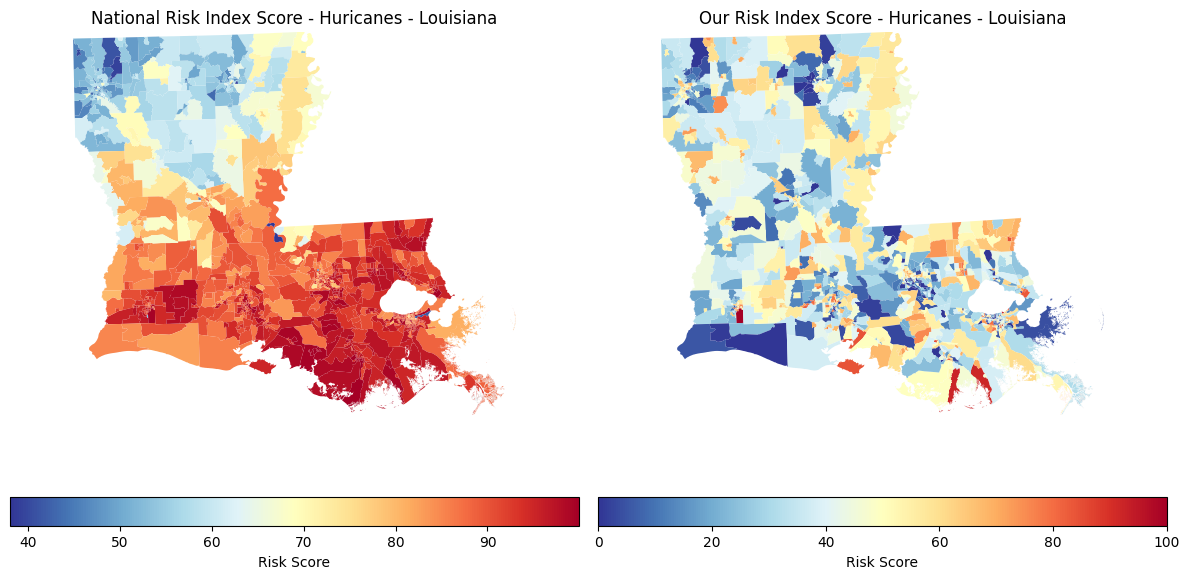

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

state_name = "Louisiana"

state_map = la_tracts_clean[la_tracts_clean["STATE"].str.lower() == state_name.lower()]

# NRI Louisiana Hurricane Risk
state_map.plot(column='HRCN_RISKS_x', ax=ax[0], legend=True,
                linewidth=0.1, cmap="RdYlBu_r",
                legend_kwds={'label': "Risk Score", 'orientation': "horizontal"},
                missing_kwds={'color': "lightgrey", 'label': "No Data"})

minx, miny, maxx, maxy = state_map.total_bounds
padding = 0.5
ax[0].set_xlim(minx-padding, maxx+padding)
ax[0].set_ylim(miny-padding, maxy+padding)
ax[0].set_title("National Risk Index Score - Huricanes - Louisiana")
ax[0].set_axis_off()

# Our Louisiana Strong Winds Risk
state_map.plot(column='new_HRCN_RISKS', ax=ax[1], legend=True,
                linewidth=0.1, cmap="RdYlBu_r",
                legend_kwds={'label': "Risk Score", 'orientation': "horizontal"},
                missing_kwds={'color': "lightgrey", 'label': "No Data"})

minx, miny, maxx, maxy = state_map.total_bounds
ax[1].set_xlim(minx-padding, maxx+padding)
ax[1].set_ylim(miny-padding, maxy+padding)
ax[1].set_title("Our Risk Index Score - Huricanes - Louisiana")
ax[1].set_axis_off()

plt.tight_layout()
plt.show()

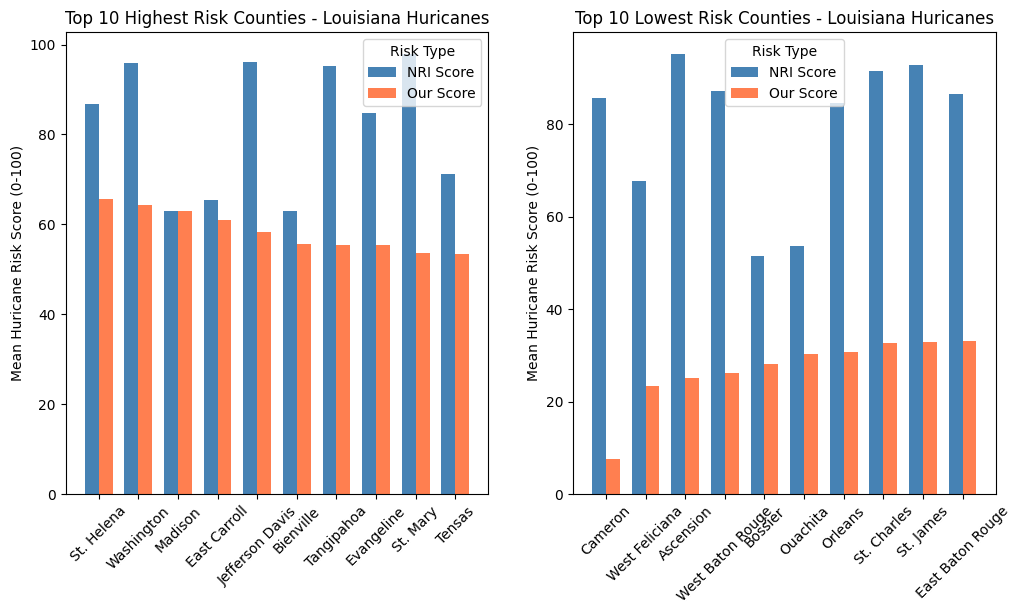

In [23]:
la_counties_huricanes = la_complete_data.groupby('COUNTY')[['HRCN_RISKS', 'new_HRCN_RISKS']].mean()
la_counties_huricanes_top = la_counties_huricanes.nlargest(10, 'new_HRCN_RISKS')
la_counties_huricanes_bottom = la_counties_huricanes.nsmallest(10, 'new_HRCN_RISKS')

fig, axes = plt.subplots(1,2,figsize=(12,6))

x = np.arange(len(la_counties_huricanes_top))
width = 0.35
axes[0].bar(x - width/2, la_counties_huricanes_top["HRCN_RISKS"], width, label="NRI Score", color="steelblue")
axes[0].bar(x + width/2, la_counties_huricanes_top["new_HRCN_RISKS"], width, label="Our Score", color="coral")
axes[0].set_xticks(x)
axes[0].set_xticklabels(la_counties_huricanes_top.index, rotation=45)
axes[0].set_ylabel("Mean Huricane Risk Score (0-100)")
axes[0].set_title("Top 10 Highest Risk Counties - Louisiana Huricanes")
axes[0].legend(title="Risk Type")


x = np.arange(len(la_counties_huricanes_bottom))
axes[1].bar(x - width/2, la_counties_huricanes_bottom["HRCN_RISKS"], width, label="NRI Score", color="steelblue")
axes[1].bar(x + width/2, la_counties_huricanes_bottom["new_HRCN_RISKS"], width, label="Our Score", color="coral")
axes[1].set_xticks(x)
axes[1].set_xticklabels(la_counties_huricanes_bottom.index, rotation=45)
axes[1].set_ylabel("Mean Huricane Risk Score (0-100)")
axes[1].set_title("Top 10 Lowest Risk Counties - Louisiana Huricanes")
axes[1].legend(title="Risk Type")